# 05 Reproduce from saved signals
## Цель ноутбука
Показать, как повторно использовать один и тот же `signals.npz` и получать сопоставимые результаты.

## Почему это важно
Если разные алгоритмы проверяются на одних и тех же сохраненных сигналах, сравнение становится честным: различия в итогах связаны с декодерами, а не с новой случайной реализацией шума.

## Что получим в конце
- два запуска: с генерацией сигналов и с повторным использованием;
- проверку совпадения результатов;
- наглядное объяснение, зачем нужен режим `reuse_saved_signals=True`.

In [1]:
# [1/8] Импорты и поиск корня проекта
from pathlib import Path
import sys
import yaml
import pandas as pd
from IPython.display import display, Image

def find_repo_root(start: Path) -> Path:
    cur = start.resolve()
    while cur != cur.parent:
        if (cur / 'pyproject.toml').exists():
            return cur
        cur = cur.parent
    raise RuntimeError('Repo root not found')

ROOT = find_repo_root(Path.cwd())
if str(ROOT / 'src') not in sys.path:
    sys.path.insert(0, str(ROOT / 'src'))

print('[1/8] Импорты загружены')
print('ROOT =', ROOT)


[1/8] Импорты загружены
ROOT = C:\Users\maks\Desktop\maga\диплом\практика\2\dp-codex-create-repository-for-neural-viterbi-and-bcjr-j6ug56


# Настройка параметров эксперимента


In [2]:
# [2/8] Параметры эксперимента (редактируются в этой ячейке)
PARAMS = {
    'run_name': 'notebook_reproduce',
    'K': 64,
    'num_blocks': 12,
    'snr_db_list': [0, 2],
    'seed': 123,
    'decoders': ['viterbi', 'bcjr', 'neural_viterbi', 'neural_bcjr'],
    'epochs': 1,
    'learning_rate': 1e-3,
    'hidden_dim': 16,
    'reuse_saved_signals': False,
    'training_enabled': True,
}
print('[2/8] Параметры заданы')
display(pd.Series(PARAMS))


[2/8] Параметры заданы


run_name                                         notebook_reproduce
K                                                                64
num_blocks                                                       12
snr_db_list                                                  [0, 2]
seed                                                            123
decoders               [viterbi, bcjr, neural_viterbi, neural_bcjr]
epochs                                                            1
learning_rate                                                 0.001
hidden_dim                                                       16
reuse_saved_signals                                           False
training_enabled                                               True
dtype: object

In [3]:
# [3/8] Загружаем YAML, меняем параметры и сохраняем notebook-конфиг
from comm_ai.utils.io import load_yaml

cfg = load_yaml(ROOT / 'src/comm_ai/config/experiments/awgn_small.yaml')
cfg['experiment']['run_name'] = PARAMS['run_name']
cfg['experiment']['K'] = PARAMS['K']
cfg['experiment']['num_blocks'] = PARAMS['num_blocks']
cfg['experiment']['snr_db_list'] = PARAMS['snr_db_list']
cfg['experiment']['seed'] = PARAMS['seed']
cfg['experiment']['decoders'] = PARAMS['decoders']
cfg['experiment']['reuse_saved_signals'] = PARAMS['reuse_saved_signals']

# Все результаты ноутбуков сохраняем в корневую папку проекта, а не рядом с ноутбуком
cfg['paths']['outputs_root'] = str(ROOT / 'outputs' / 'runs')

cfg['training']['enabled'] = PARAMS['training_enabled']
cfg['training']['epochs'] = PARAMS['epochs']
cfg['training']['learning_rate'] = PARAMS['learning_rate']
cfg['training']['hidden_dim'] = PARAMS['hidden_dim']

nb_cfg_path = ROOT / 'outputs/runs' / f"{PARAMS['run_name']}_notebook_config.yaml"
nb_cfg_path.parent.mkdir(parents=True, exist_ok=True)
nb_cfg_path.write_text(yaml.safe_dump(cfg, sort_keys=False), encoding='utf-8')
print('[3/8] Конфиг сохранён в', nb_cfg_path)


[3/8] Конфиг сохранён в C:\Users\maks\Desktop\maga\диплом\практика\2\dp-codex-create-repository-for-neural-viterbi-and-bcjr-j6ug56\outputs\runs\notebook_reproduce_notebook_config.yaml


In [4]:
# [4/8] Первый запуск: генерируем сигнал
from comm_ai.experiments.run_experiment import run
cfg['experiment']['reuse_saved_signals'] = False
nb_cfg_path.write_text(yaml.safe_dump(cfg, sort_keys=False), encoding='utf-8')
out_first = run(str(nb_cfg_path))
print('[4/8] Первый запуск завершён')


train_neural_bcjr: 100%|██████████| 1/1 [00:00<00:00, 531.19it/s]


[4/8] Первый запуск завершён


In [5]:
# [5/8] Второй запуск: переиспользуем сохранённый signals.npz
cfg['experiment']['reuse_saved_signals'] = True
nb_cfg_path.write_text(yaml.safe_dump(cfg, sort_keys=False), encoding='utf-8')
out_second = run(str(nb_cfg_path))
print('[5/8] Второй запуск завершён')


[5/8] Второй запуск завершён


In [6]:
# [6/8] Сравниваем результаты
r1 = pd.read_csv(out_first / 'results.csv')
r2 = pd.read_csv(out_second / 'results.csv')
print('Совпадение таблиц результатов:', r1.equals(r2))
display(r1)

Results identical: True


,decoder,snr_db,ber,fer,decode_time_s,complexity_proxy,trained_model_used
0,bcjr,0.0,0.248698,0.833333,0.101093,4096,False
1,bcjr,2.0,0.022135,0.250000,0.101972,4096,False
2,neural_bcjr,0.0,0.244792,0.833333,0.112942,4096,True
3,neural_bcjr,2.0,0.089844,0.416667,0.109794,4096,True
4,neural_viterbi,0.0,0.269531,0.833333,0.030261,4096,True
5,neural_viterbi,2.0,0.022135,0.250000,0.029294,4096,True
6,viterbi,0.0,0.256510,0.833333,0.025694,4096,False
7,viterbi,2.0,0.022135,0.250000,0.025638,4096,False


### Как интерпретировать проверку совпадения
Если таблицы результатов совпали, значит повторный запуск действительно использовал те же сохраненные сигналы. Это важный шаг для воспроизводимости и честного сравнения алгоритмов на идентичных входных данных.

BER/FER/Timing для воспроизводимого сценария


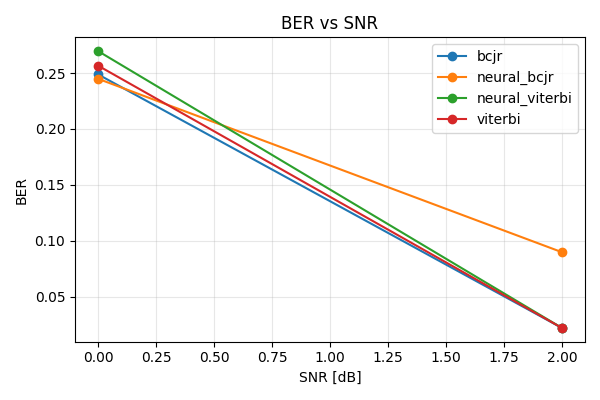

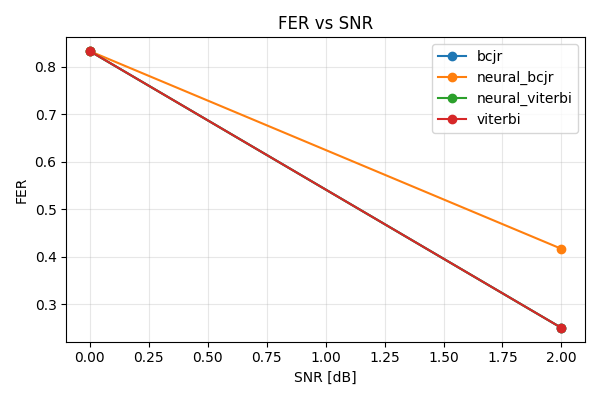

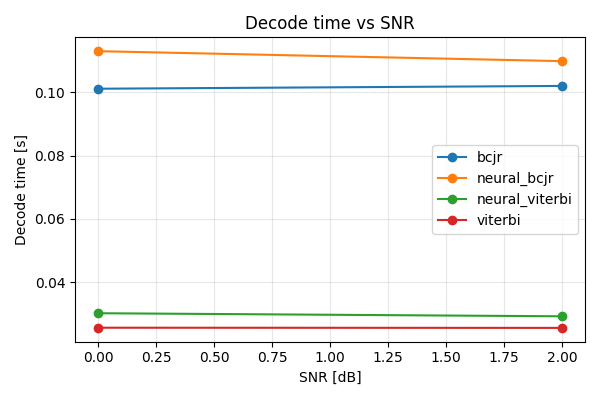

In [7]:
# [7/8] Показываем графики второго запуска
out_dir = out_second
print('Графики для повторного запуска на сохраненных сигналах')
print('BER: качество восстановления битов')
display(Image(filename=str(out_dir / 'ber_plot.png')))
print('FER: доля блоков, в которых есть хотя бы одна ошибка')
display(Image(filename=str(out_dir / 'fer_plot.png')))
print('Decode time [s]: среднее время декодирования в секундах')
display(Image(filename=str(out_dir / 'timing_plot.png')))

## Итог
Этот ноутбук показывает не новый алгоритм, а корректную исследовательскую практику: сохраненные сигналы позволяют запускать разные декодеры на одной и той же выборке и затем сравнивать их без влияния новой случайной генерации.

## Итог по воспроизводимости
Когда используется один и тот же `signals.npz`, эксперимент можно повторить и проверить. Если результаты совпадают, это подтверждает, что пайплайн воспроизводим, а сравнение алгоритмов выполнено на одинаковых входных данных.